# IBM HR Employee Attrition Analysis

This notebook explores IBM HR employee attrition through data preparation, exploratory analysis, and predictive modeling. The models identify patterns in this dataset; their risk scores are exploratory and should not be treated as causal findings or employment decisions.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Helper Functions

In [2]:
# Detect outliers in all numeric columns
def detect_outliers(df):
    results = []

    for col in df.select_dtypes(include=np.number).columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

        results.append({
            "Column": col,
            "Lower Limit": round(lower, 2),
            "Upper Limit": round(upper, 2),
            "Outliers": outlier_count
        })

    return pd.DataFrame(results).sort_values(
        "Outliers", ascending=False
    ).reset_index(drop=True)

## 2. Load and Prepare Data

In [3]:
file_path= "/Users/yezawmyint/Data Analyst/Datasets/IBM HR Analytics Employee Attrition & Performance.csv"
df= pd.read_csv(file_path)
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Data Checks and Preparation

In [4]:
# Row & Columns
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}\n")
# Check Duplication
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count:,}\n")
# Columns data-types
df.dtypes

Rows: 1,470
Columns: 35

Duplicate Rows: 0



Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [5]:
df = df[['EmployeeNumber', 'Age', 'Gender', 'MaritalStatus',
         'Education', 'EducationField', 'DistanceFromHome', 'Department',
         'JobRole', 'JobLevel', 'MonthlyIncome', 'PercentSalaryHike',
         'StockOptionLevel', 'BusinessTravel', 'OverTime',
         'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany',
         'YearsInCurrentRole', 'YearsSinceLastPromotion',
         'YearsWithCurrManager', 'PerformanceRating',
         'TrainingTimesLastYear', 'EnvironmentSatisfaction',
         'JobInvolvement', 'JobSatisfaction',
         'RelationshipSatisfaction', 'WorkLifeBalance', 'Attrition']
        ].set_index('EmployeeNumber')


In [6]:
# Row & Columns
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}\n")

Rows: 1,470
Columns: 28



In [7]:
# Encoding
df['Attrition']= df['Attrition'].map({'Yes':1,'No':0})

In [8]:
df.head()

,Age,Gender,MaritalStatus,Education,EducationField,DistanceFromHome,Department,JobRole,JobLevel,MonthlyIncome,...,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,TrainingTimesLastYear,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,Attrition
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
1,41,Female,Single,2,Life Sciences,1,Sales,Sales Executive,2,5993,...,0,5,3,0,2,3,4,1,1,1
2,49,Male,Married,1,Life Sciences,8,Research & Development,Research Scientist,2,5130,...,1,7,4,3,3,2,2,4,3,0
4,37,Male,Single,2,Other,2,Research & Development,Laboratory Technician,1,2090,...,0,0,3,3,4,2,3,2,3,1
5,33,Female,Married,4,Life Sciences,3,Research & Development,Research Scientist,1,2909,...,3,0,3,3,4,3,3,3,3,0
7,27,Male,Married,1,Medical,2,Research & Development,Laboratory Technician,1,3468,...,2,2,3,3,1,3,2,4,3,0


In [9]:
df.tail()

,Age,Gender,MaritalStatus,Education,EducationField,DistanceFromHome,Department,JobRole,JobLevel,MonthlyIncome,...,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,TrainingTimesLastYear,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,Attrition
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
2061,36,Male,Married,2,Medical,23,Research & Development,Laboratory Technician,2,2571,...,0,3,3,3,3,4,4,3,3,0
2062,39,Male,Married,1,Medical,6,Research & Development,Healthcare Representative,3,9991,...,1,7,3,5,4,2,1,1,3,0
2064,27,Male,Married,3,Life Sciences,4,Research & Development,Manufacturing Director,2,6142,...,0,3,4,0,2,4,2,2,3,0
2065,49,Male,Married,3,Medical,2,Sales,Sales Executive,2,5390,...,0,8,3,3,4,2,2,4,2,0
2068,34,Male,Married,3,Medical,8,Research & Development,Laboratory Technician,2,4404,...,1,2,3,3,2,4,3,1,4,0


In [10]:
# # Decoding
# education_mapping = {
#     1: "Below College",
#     2: "College",
#     3: "Bachelor",
#     4: "Master",
#     5: "Doctor"
# }
# job_level_mapping={
#     1: "Entry",
#     2: "Junior",
#     3: "Mid level",
#     4: "Senior",
#     5: "Executive"
# }
# stock_option_mapping={
#     0: "No stock options",
#     1: "Lower stock-option tier",
#     2: "Medium stock-option tier",
#     3: "Higher stock-option tier"
# }

# df["Education"] = df["Education"].map(education_mapping)
# df["JobLevel"] = df["JobLevel"].map(job_level_mapping)
# df["StockOptionLevel"] = df["StockOptionLevel"].map(stock_option_mapping)
# df.head(10)

## 3. Exploratory Data Analysis

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.0,25.0
StockOptionLevel,1470.0,0.793878,0.852077,0.0,0.0,1.0,1.0,3.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0


### Survey Ratings

In [34]:
survey_columns = [
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

survey_summary = (
    df[survey_columns]
    .mean()
    .sort_values(ascending=False)
    .to_frame("Mean Rating")
    .round(2)
)

# Interpret the mean rating
def interpret_rating(mean):
    if mean <= 1.75:
        return "Very Low / Very Negative"
    elif mean <= 2.50:
        return "Low / Negative"
    elif mean <= 3.25:
        return "Moderate / Neutral"
    else:
        return "High / Positive"

survey_summary["Interpretation"] = survey_summary["Mean Rating"].apply(interpret_rating)

display(survey_summary)

,Mean Rating,Interpretation
WorkLifeBalance,2.76,Moderate / Neutral
JobInvolvement,2.73,Moderate / Neutral
JobSatisfaction,2.73,Moderate / Neutral
EnvironmentSatisfaction,2.72,Moderate / Neutral
RelationshipSatisfaction,2.71,Moderate / Neutral


### Overall Attrition

In [12]:
total_employee_count = len(df)
attrition_count = df["Attrition"].sum()
attrition_rate = attrition_count / total_employee_count * 100

summary = pd.DataFrame({
    "Metric": ["Total Employees", "Attrition Count", "Attrition Rate"],
    "Value": [
        total_employee_count,
        attrition_count,
        f"{attrition_rate:.2f}%"
    ]
})

summary

,Metric,Value
0,Total Employees,1470
1,Attrition Count,237
2,Attrition Rate,16.12%


### Attrition by Job Role

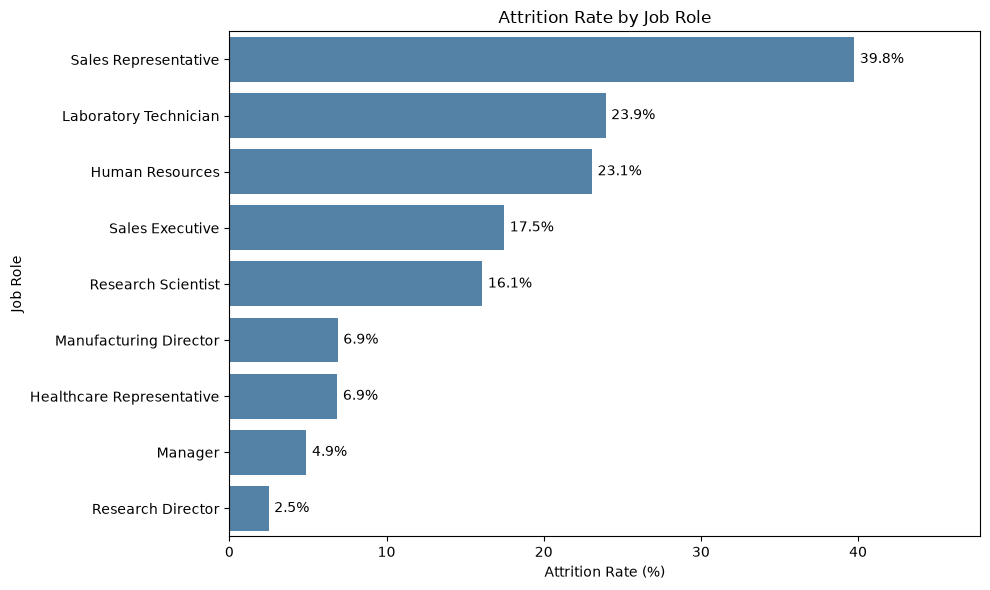

In [16]:
# Attrition By Role
attrition_by_job_role = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False)
      .mul(100)
      .rename("Attrition Rate (%)")
      .reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=attrition_by_job_role,
    x="Attrition Rate (%)",
    y="JobRole",
    color="steelblue"
)

ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=4)
ax.set_title("Attrition Rate by Job Role")
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("Job Role")
ax.set_xlim(0, attrition_by_job_role["Attrition Rate (%)"].max() + 8)

plt.tight_layout()
plt.show()

### Salary Outliers

In [39]:
# Outliers
from scipy.stats import iqr
df_salary = df.groupby('EmployeeNumber')['MonthlyIncome'].sum()
# Calculate the interquartile range and outlier boundaries
iqr_total_salary = iqr(df_salary)
upper_limit = np.quantile(df_salary, 0.75) + 1.5 * iqr_total_salary
lower_limit = np.quantile(df_salary, 0.25) - 1.5 * iqr_total_salary

# Store customers whose spending is outside the IQR boundaries
outliers = []
for employee, total_salary in df_salary.items():
    if total_salary < lower_limit or total_salary > upper_limit:
        outliers.append(employee)
print('Monthly Salary Outliers are:')
outlier_job_roles = (
    df.loc[df.index.isin(outliers), "JobRole"]
      .value_counts()
      .rename_axis("Job Role")
      .reset_index(name="Employee Count")
)

print(outlier_job_roles)
# Most are Managers and Research Directors
df.loc[df.index.isin(outliers), ["JobRole", "MonthlyIncome", "Attrition"]].reset_index()

Monthly Salary Outliers are:
            Job Role  Employee Count
0            Manager              74
1  Research Director              40


,EmployeeNumber,JobRole,MonthlyIncome,Attrition
0,32,Manager,19094,0
1,38,Manager,18947,0
2,58,Research Director,19545,1
3,80,Research Director,18740,0
4,140,Manager,18844,0
...,...,...,...,...
109,1938,Manager,17875,0
110,1941,Research Director,19161,0
111,1973,Manager,19636,0
112,2022,Manager,19431,0


### Feature Correlations

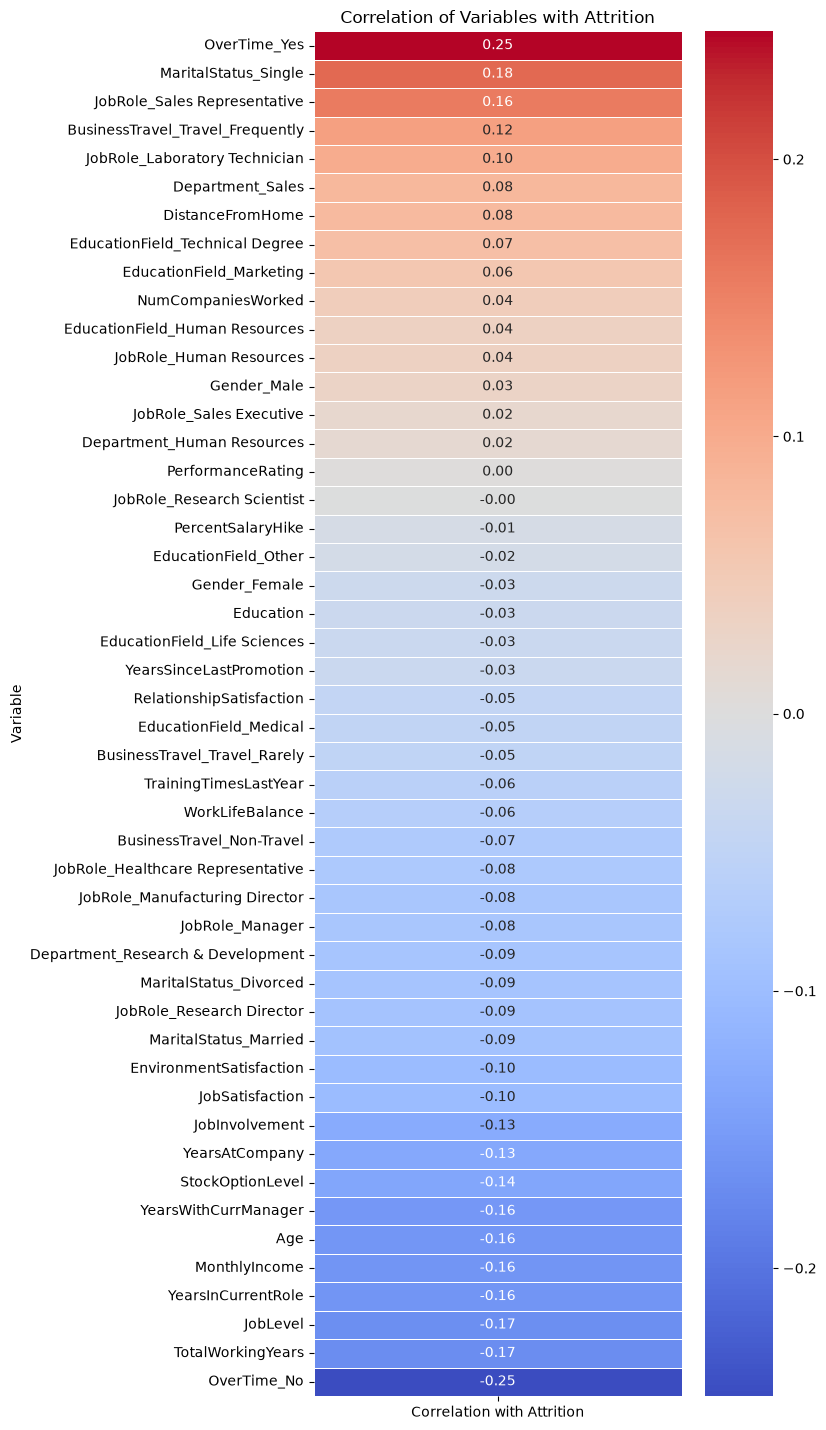

In [15]:
# One-hot encode categorical predictors, excluding the target and derived outlier flag
features = df.drop(columns=["Attrition", "outlier"], errors="ignore")
# Convert Category into dummy numeric
encoded_features = pd.get_dummies(features, drop_first=False, dtype=int)

# Correlation of each feature with Attrition
attrition_correlations = (
    encoded_features
    .corrwith(df["Attrition"])
    .dropna()
    .sort_values(ascending= False)
    .rename("Correlation with Attrition")
    .to_frame()
)

# display(attrition_correlations.round(2))

# Heatmap of feature correlations with Attrition
plt.figure(figsize=(8, max(6, len(attrition_correlations) * 0.3)))
sns.heatmap(
    attrition_correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4
)
plt.title("Correlation of Variables with Attrition")
plt.xlabel("")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 4. Optional Model Checks
These models are supporting analysis, not an employee-screening tool. On the held-out test set, logistic regression ranked attrition risk better (ROC-AUC 0.814) than the decision tree (0.692), but attrition precision was only 0.38 and 0.29, respectively. Many employees flagged by these models did not leave. Treat scores as exploratory signals, not facts about individuals.

### Logistic Regression

              precision    recall  f1-score   support

           0       0.93      0.79      0.85       247
           1       0.38      0.68      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294

ROC-AUC: 0.814


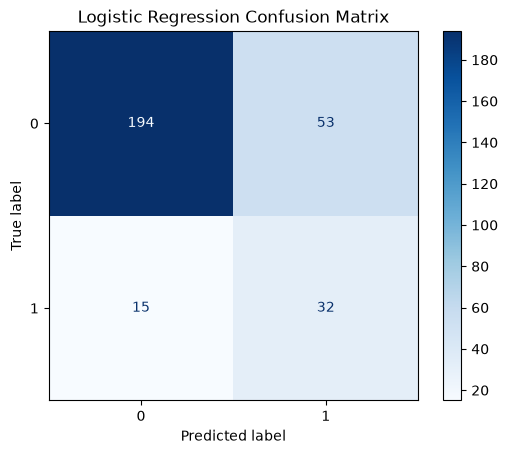

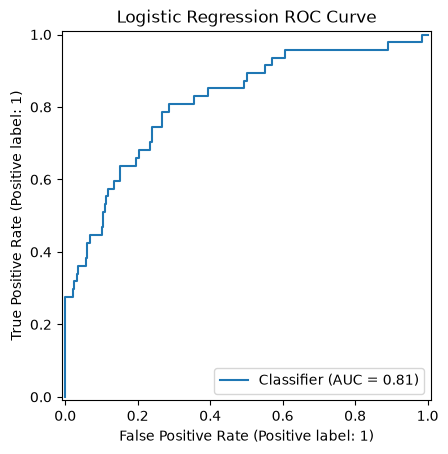

,EmployeeNumber,Attrition Risk (%),Actual Attrition
0,478,99.221031,Yes
1,1273,98.777446,Yes
2,959,96.020132,Yes
3,702,94.938426,Yes
4,1439,94.717400,Yes
5,1318,94.591842,Yes
6,1053,93.921358,Yes
7,175,93.585204,Yes
8,720,91.617621,Yes
9,248,91.524161,Yes


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

X = df.drop(columns="Attrition")
y = df["Attrition"]

numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Logistic Regression ROC Curve")
plt.show()

# Rank held-out employees by predicted probability of attrition
employee_risk = pd.DataFrame({
    "EmployeeNumber": X_test.index,
    "Attrition Risk (%)": y_prob * 100,
    "Actual Attrition": y_test.reindex(X_test.index).map({0: "No", 1: "Yes"}).to_numpy()
}).sort_values("Attrition Risk (%)", ascending=False)

display(employee_risk.head(20).reset_index(drop=True))

### Hierarchical Clustering
Cluster employee profiles without using the attrition outcome, then compare attrition rates across the resulting groups.

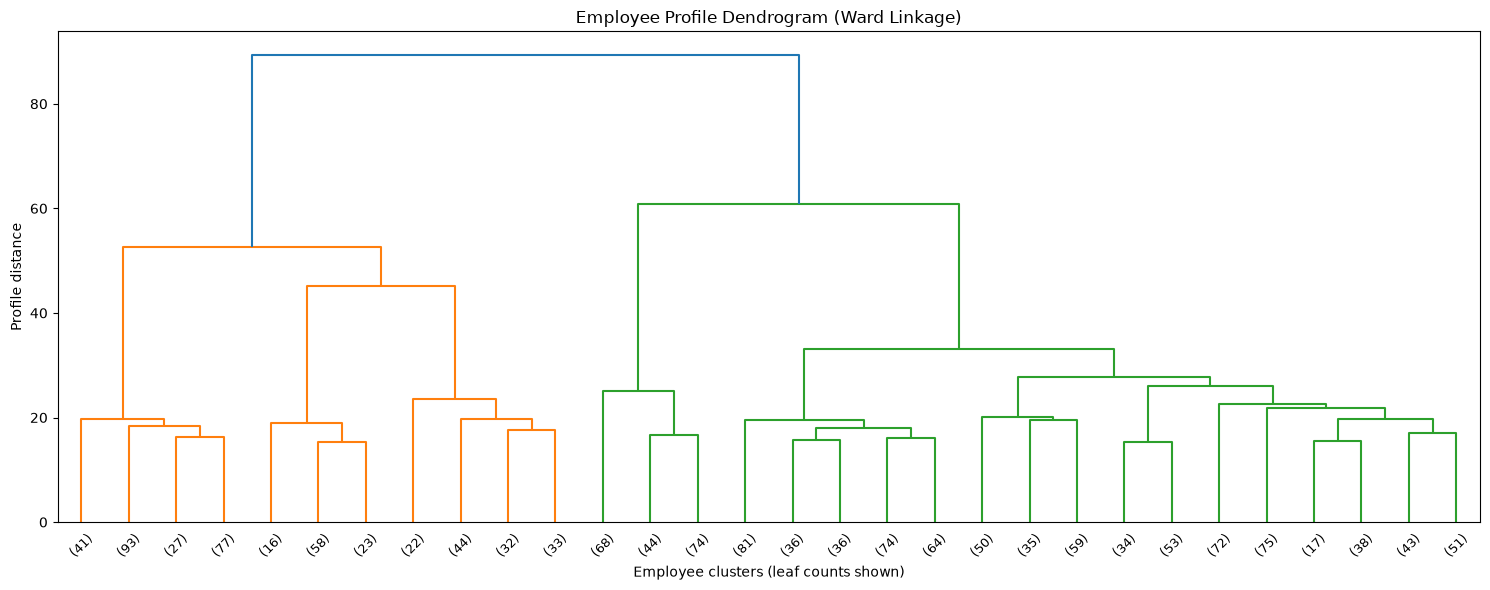

,Employee_Count,Attrition_Count,Attrition Rate (%)
Cluster,,,
4,818,166,20.3
3,186,37,19.9
2,228,17,7.5
1,238,17,7.1


In [38]:
# Hierarchical clustering: group similar employee profiles without using Attrition
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

cluster_features = logistic_model.named_steps["preprocessor"].transform(X)
if hasattr(cluster_features, "toarray"):
    cluster_features = cluster_features.toarray()

linkage_matrix = linkage(cluster_features, method="ward")
cluster_labels = fcluster(linkage_matrix, t=4, criterion="maxclust")

plt.figure(figsize=(15, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    show_leaf_counts=True,
    leaf_font_size=9
)
plt.title("Employee Profile Dendrogram (Ward Linkage)")
plt.xlabel("Employee clusters (leaf counts shown)")
plt.ylabel("Profile distance")
plt.tight_layout()
plt.show()

cluster_summary = (
    pd.DataFrame({"Cluster": cluster_labels, "Attrition": y.to_numpy()})
    .groupby("Cluster")
    .agg(
        Employee_Count=("Attrition", "size"),
        Attrition_Count=("Attrition", "sum"),
        Attrition_Rate=("Attrition", "mean")
    )
)
cluster_summary["Attrition Rate (%)"] = (cluster_summary.pop("Attrition_Rate") * 100).round(1)
display(cluster_summary.sort_values("Attrition Rate (%)", ascending=False))

### Decision Tree
A shallow, class-balanced tree gives readable attrition rules and employee risk scores. Its metrics use the same held-out test set as the logistic regression.

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       247
           1       0.29      0.60      0.39        47

    accuracy                           0.70       294
   macro avg       0.59      0.66      0.59       294
weighted avg       0.80      0.70      0.73       294

Decision Tree ROC-AUC: 0.692


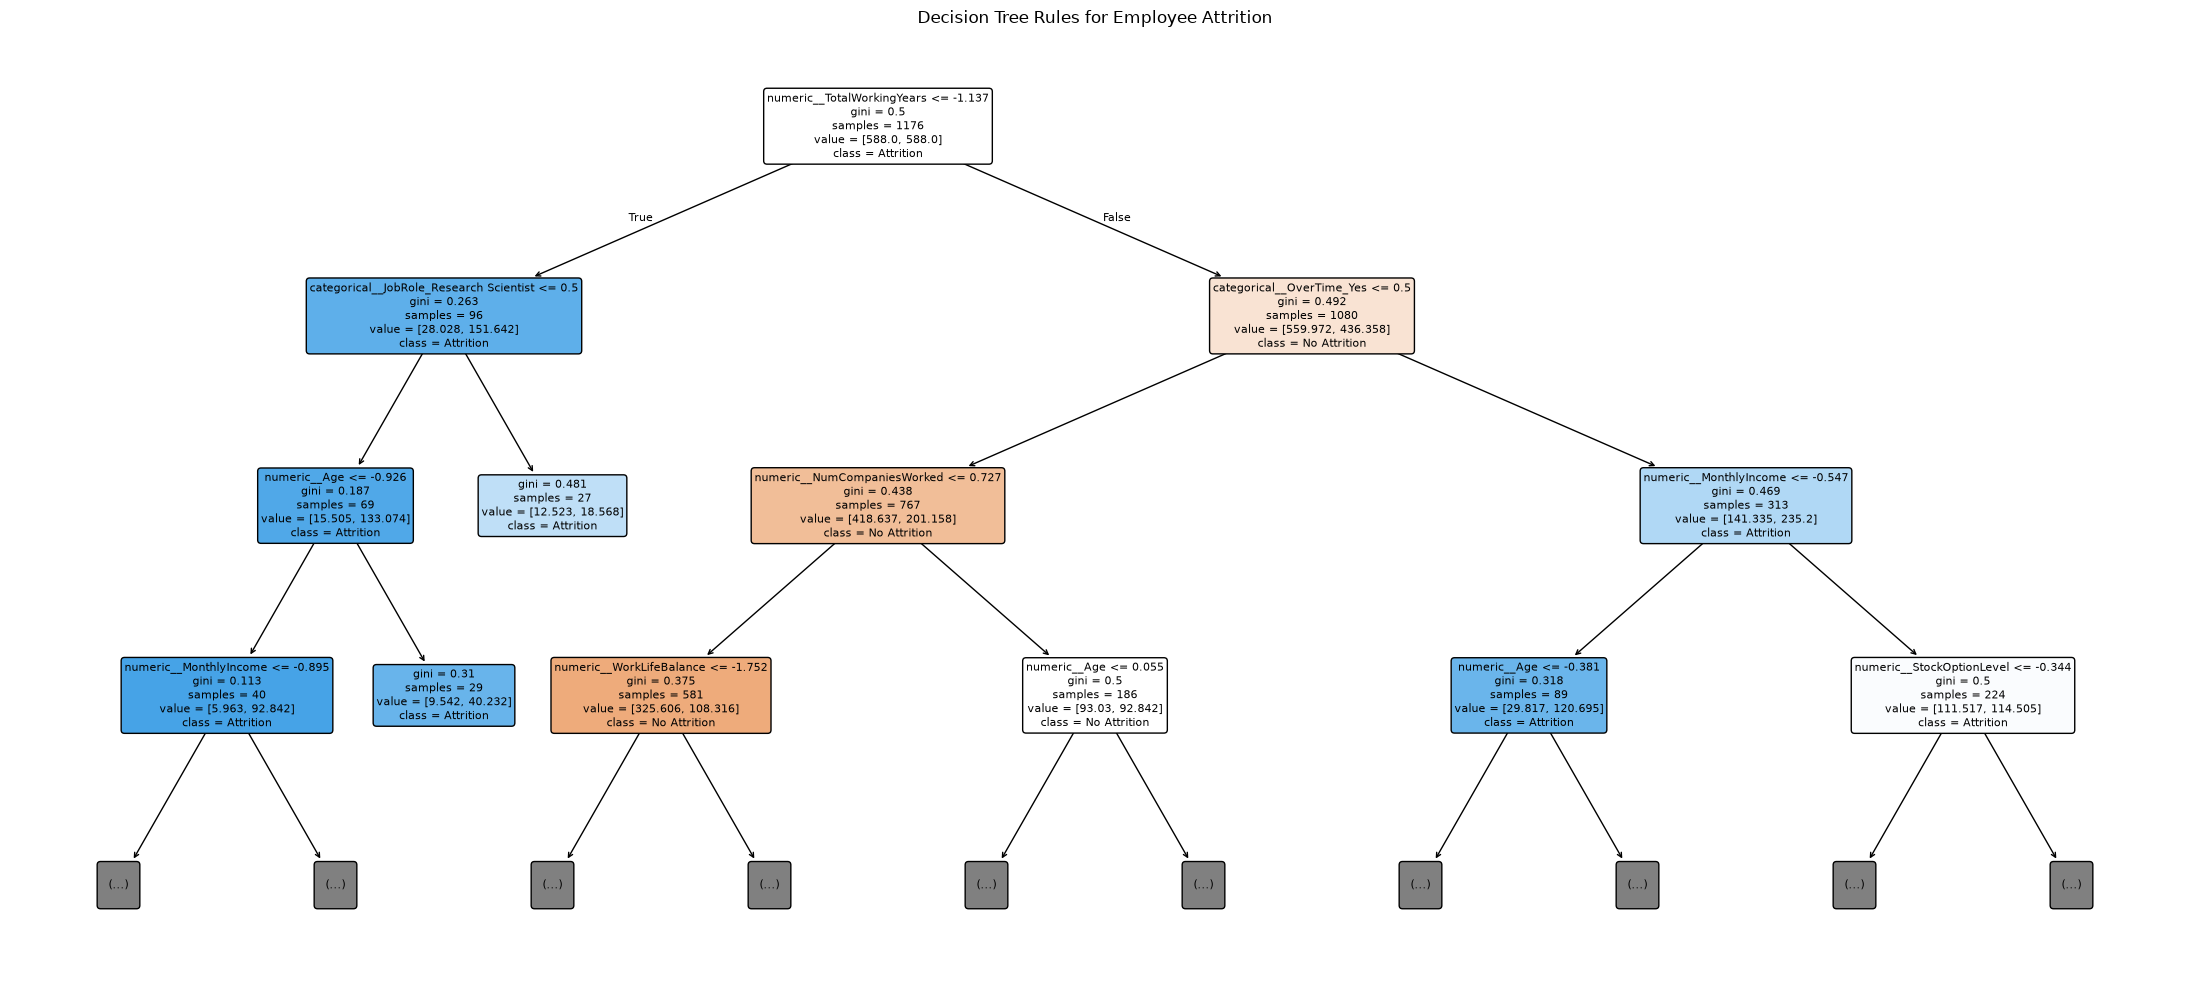

,Feature,Importance
0,numeric__TotalWorkingYears,0.285874
1,categorical__OverTime_Yes,0.240282
2,numeric__Age,0.125770
3,numeric__StockOptionLevel,0.094604
4,numeric__NumCompaniesWorked,0.092553
5,numeric__MonthlyIncome,0.090777
6,numeric__WorkLifeBalance,0.044055
7,categorical__JobRole_Research Scientist,0.026085
8,numeric__JobLevel,0.000000
9,categorical__JobRole_Laboratory Technician,0.000000


,EmployeeNumber,Attrition Risk (%),Actual Attrition
0,1495,96.711285,No
1,411,96.711285,No
2,1056,96.711285,No
3,54,96.711285,No
4,643,96.711285,No
5,1273,96.711285,Yes
6,959,96.711285,Yes
7,1296,90.599378,No
8,22,90.599378,No
9,144,90.599378,No


In [40]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train and evaluate a shallow, class-balanced decision tree
tree_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ))
])
tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)
tree_probabilities = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Classification Report:")
print(classification_report(y_test, tree_predictions))
print(f"Decision Tree ROC-AUC: {roc_auc_score(y_test, tree_probabilities):.3f}")

# Visualize the main decision rules
tree_feature_names = tree_model.named_steps["preprocessor"].get_feature_names_out()
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model.named_steps["classifier"],
    feature_names=tree_feature_names,
    class_names=["No Attrition", "Attrition"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Rules for Employee Attrition")
plt.tight_layout()
plt.show()

# Rank the most influential tree features
tree_importance = (
    pd.Series(
        tree_model.named_steps["classifier"].feature_importances_,
        index=tree_feature_names,
        name="Importance"
    )
    .sort_values(ascending=False)
    .head(15)
    .rename_axis("Feature")
    .reset_index()
)
display(tree_importance)

# Rank held-out employees by estimated attrition probability
tree_employee_risk = pd.DataFrame({
    "EmployeeNumber": X_test.index,
    "Attrition Risk (%)": tree_probabilities * 100,
    "Actual Attrition": y_test.reindex(X_test.index).map({0: "No", 1: "Yes"}).to_numpy()
}).sort_values("Attrition Risk (%)", ascending=False)
display(tree_employee_risk.head(20).reset_index(drop=True))

## 5. Conclusion for HR

### Key Findings
- In this dataset, 237 of 1,470 employees left, an attrition rate of 16.12%.
- Average survey ratings range from 2.71 to 2.76 and are classified as moderate/neutral. These averages may hide teams or employee groups with lower experiences.
- The four employee clusters have different historical attrition rates: 19.9% and 20.3% in the two higher-rate clusters, compared with 7.1% and 7.5% in the other two. Cluster numbers alone do not explain what distinguishes those groups.
- The decision tree gives the most weight to total working years, overtime, age, stock option level, and number of companies worked. These are associations in this dataset, not proof that changing any one factor will prevent attrition.

### Recommended Follow-Up
- Review overtime and workload patterns alongside stay interviews, manager feedback, and team-level attrition rates.
- Profile the higher-attrition clusters by job role, tenure, and working conditions before designing targeted support.
- Check satisfaction and retention patterns at team and role level; use averages as a starting point, not a complete picture.
- Refresh the analysis with current workforce data and validate any proposed intervention over time.

### Cautions
- The data is observational: it can show relationships, not causes.
- Model precision is low, so many people identified as higher risk did not leave in the test data. Do not use model scores to make decisions about individual employees.
- The salary outliers are mostly Managers and Research Directors; unusually high income is not, by itself, evidence of attrition risk.